In [3]:
# Environment & imports
import sys
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Python excecutable:", sys.executable)

sys.path.append(str(Path.cwd().parent))
from src.simulation import simulate_sir, choose_immunized_by_degree, choose_immunized_random, choose_immunized_by_eigenvector_centrality

Python excecutable: /Users/nemodelingat/miniconda3/envs/ffg/bin/python3.11


In [4]:
import pandas as pd
import networkx as nx
from itertools import combinations

base = "../data/WY/56001"

p = pd.read_csv(f"{base}/people.txt", sep="\t")
gqp = pd.read_csv(f"{base}/gq_people.txt", sep="\t")

edges = []
for _, r in p.iterrows():
  pid = f"P:{r.sp_id}"
  edges.append((pid, f"H:{r.sp_hh_id}", "household"))
  if r.school_id != "X":
      edges.append((pid, f"S:{r.school_id}", "school"))
  if r.work_id != "X":
      edges.append((pid, f"W:{r.work_id}", "work"))

for _, r in gqp.iterrows():
  edges.append((f"P:{r.sp_id}", f"G:{r.sp_gq_id}", "gq"))

B = nx.Graph()
for u, v, t in edges:
  B.add_node(u, kind="person")
  B.add_node(v, kind="place")
  B.add_edge(u, v, rel=t)

# person-person projection
G_p = nx.Graph()
places = [n for n, d in B.nodes(data=True) if d["kind"] == "place"]
for place in places:
  people = [n for n in B.neighbors(place) if B.nodes[n]["kind"] == "person"]
  rel = place.split(":")[0]
  for a, b in combinations(people, 2):
      if G_p.has_edge(a, b):
          G_p[a][b]["weight"] += 1
          G_p[a][b]["rels"].add(rel)
      else:
          G_p.add_edge(a, b, weight=1, rels={rel})

print("bipartite:", B.number_of_nodes(), B.number_of_edges())
print("person-person:", G_p.number_of_nodes(), G_p.number_of_edges())



bipartite: 54261 59946
person-person: 33961 4735491


In [5]:
largest_nodes = max(nx.connected_components(G_p), key=len)
G_sub = G_p.subgraph(largest_nodes).copy()
print(G_sub.number_of_nodes())

largest_nodes = max(nx.connected_components(G_sub), key=len)
G_sub = G_p.subgraph(largest_nodes).copy()
print(G_sub.number_of_nodes())

28901
28901


In [6]:
n = 400
p = 0.01
#G = nx.erdos_renyi_graph(n, p)  # undirected random graph
G = G_sub
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Avg degree:", sum(dict(G.degree()).values()) / n)


Nodes: 28901
Edges: 2758799
Avg degree: 13793.995


In [7]:
G.nodes(0)

NodeDataView({'P:164104833': None, 'P:164104834': None, 'P:251338078': None, 'P:292906984': None, 'P:125996025': None, 'P:149107068': None, 'P:153860487': None, 'P:199277199': None, 'P:238160327': None, 'P:357771563': None, 'P:149498050': None, 'P:164104835': None, 'P:164104836': None, 'P:189390351': None, 'P:318866601': None, 'P:374817105': None, 'P:126249552': None, 'P:157779778': None, 'P:192056232': None, 'P:286203978': None, 'P:307683401': None, 'P:374816965': None, 'P:411910565': None, 'P:125674715': None, 'P:163619078': None, 'P:205877518': None, 'P:223705854': None, 'P:291513817': None, 'P:324050450': None, 'P:360721071': None, 'P:394782496': None, 'P:135531384': None, 'P:154697576': None, 'P:219048744': None, 'P:228819418': None, 'P:236000122': None, 'P:248283579': None, 'P:281980005': None, 'P:162669456': None, 'P:164104841': None, 'P:164104842': None, 'P:166675188': None, 'P:167347545': None, 'P:171982894': None, 'P:172412231': None, 'P:184368006': None, 'P:185480573': None,

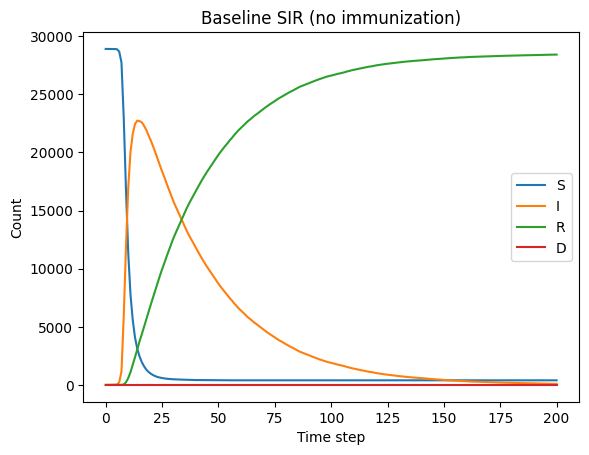

In [8]:
beta = 0.2
gamma = 0.03
steps = 200

initial_infected = ['P:164104833']          # seed infection at node 0
rng = np.random.default_rng(42) # reproducible run

out0 = simulate_sir(
    G,
    beta=beta,
    gamma=gamma,
    steps=steps,
    initial_infected=initial_infected,
    immunized=set(),
    rng=rng
)

plt.plot(out0["S"], label="S")
plt.plot(out0["I"], label="I")
plt.plot(out0["R"], label="R")
plt.plot(out0["D"], label="D")
plt.title("Baseline SIR (no immunization)")
plt.xlabel("Time step")
plt.ylabel("Count")
plt.legend()
plt.show()

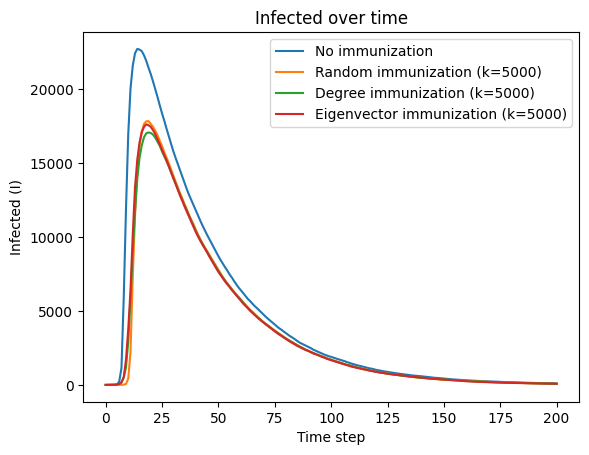

In [14]:
k = 5000
immunized_random = choose_immunized_random(G, k)
immunized_by_degree = choose_immunized_by_degree(G, k)
immunized_by_eigenvector_centrality = choose_immunized_by_eigenvector_centrality(G, k)


out_deg_r = simulate_sir(
    G,
    beta=beta,
    gamma=gamma,
    steps=steps,
    initial_infected=initial_infected,
    immunized=immunized_random,
    rng=np.random.default_rng(42)  
)
out_deg_d = simulate_sir(
    G,
    beta=beta,
    gamma=gamma,
    steps=steps,
    initial_infected=initial_infected,
    immunized=immunized_by_degree,
    rng=np.random.default_rng(42) 
)
out_deg_e = simulate_sir(
    G,
    beta=beta,
    gamma=gamma,
    steps=steps,
    initial_infected=initial_infected,
    immunized=immunized_by_eigenvector_centrality,
    rng=np.random.default_rng(42)
)
plt.plot(out0["I"], label="No immunization")
plt.plot(out_deg_r["I"], label=f"Random immunization (k={k})")
plt.plot(out_deg_d["I"], label=f"Degree immunization (k={k})")
plt.plot(out_deg_e["I"], label=f"Eigenvector immunization (k={k})")
plt.title("Infected over time")
plt.xlabel("Time step")
plt.ylabel("Infected (I)")
plt.legend()
plt.show()


In [ ]:
def peak_infected(out):
    return max(out["I"])

k_values = list(range(0, 81, 5))
peaks = []

for k in k_values:
    imm = choose_immunized_by_degree(G, k)
    out = simulate_sir(
        G, beta, gamma, steps, initial_infected,
        immunized=imm,
        rng=np.random.default_rng(42)  # keep fixed for comparability
    )
    peaks.append(peak_infected(out))

plt.plot(k_values, peaks, marker="o")
plt.title("Peak infected vs number immunized (degree targeting)")
plt.xlabel("k immunized")
plt.ylabel("Peak infected")
plt.show()
